# Segmentation Merge-Split P2: **K-MEANS, GAUSSIAN MIXTURE MODEL (GMM), MEAN SHIFT**

# K-Means Clustering

### 1. Kiến thức cơ bản về K-Means
**K-Means** là một trong những thuật toán học không giám sát (Unsupervised Learning) phổ biến và đơn giản nhất được sử dụng để giải quyết bài toán gom cụm (Clustering). Mục tiêu của thuật toán là chia bộ dữ liệu thành $K$ cụm (clusters) riêng biệt sao cho các điểm dữ liệu trong cùng một cụm có tính chất giống nhau nhất có thể.

### 2. Thuật toán hoạt động như thế nào?
Thuật toán K-Means là một quá trình lặp đi lặp lại (Iterative process) bao gồm các bước sau:
1. **Khởi tạo:** Chọn ngẫu nhiên $K$ điểm dữ liệu làm các tâm cụm (centroids) ban đầu.
2. **Gán cụm (Assignment):** Tính khoảng cách (thường là khoảng cách Euclidean) từ mỗi điểm dữ liệu đến $K$ tâm cụm, và gán điểm đó vào cụm có tâm gần nó nhất.
3. **Cập nhật tâm (Update):** Tính toán lại vị trí của các tâm cụm bằng cách lấy trung bình tọa độ của tất cả các điểm dữ liệu đã được gán vào cụm đó.
4. **Lặp lại:** Lặp lại bước 2 và 3 cho đến khi các tâm cụm không còn thay đổi vị trí nữa (hội tụ - convergence).

### 3. Ưu và nhược điểm
- **Ưu điểm:** Tốc độ tính toán rất nhanh, đơn giản, dễ cài đặt, đặc biệt hiệu quả với dữ liệu lớn.
- **Nhược điểm:** Phải tự định nghĩa số lượng cụm $K$ từ trước. Thuật toán giả định các cụm có hình cầu (spherical) nên thường hoạt động không tốt nếu các cụm dữ liệu kéo dài hoặc có kích thước/mật độ chênh lệch nhau quá nhiều (đây là lý do GMM ra đời để khắc phục).

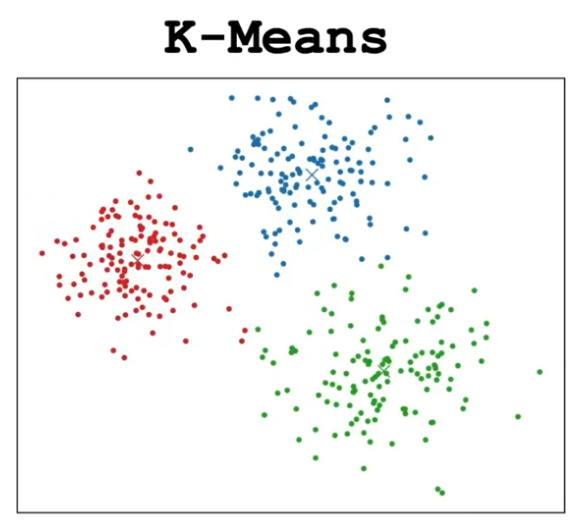


### Cell 1: Import thư viện
**Mục đích:** Nạp các thư viện cần thiết cho việc xử lý ảnh, tính toán ma trận và vẽ đồ thị.
**Cách hoạt động:** 
- `cv2` (OpenCV): Dùng để đọc và chuyển đổi không gian màu của ảnh.
- `numpy`: Dùng để xử lý dữ liệu ảnh dưới dạng ma trận số.
- `matplotlib.pyplot`: Dùng để hiển thị ảnh và vẽ các biểu đồ phân bố điểm ảnh (scatter plot).

In [68]:
# Cell 1

import cv2
import numpy as np
import matplotlib.pyplot as plt

### Cell 2: Đọc ảnh và chuyển đổi không gian màu
**Mục đích:** Đọc ảnh từ ổ cứng và chuẩn bị dữ liệu màu sắc tốt nhất cho thuật toán K-Means.
**Cách hoạt động:** 
- `cv2.imread()` đọc ảnh dưới định dạng BGR. Sau đó dùng `cv2.cvtColor()` để chuyển sang RGB (để hiển thị đúng màu bằng matplotlib).
- Tiếp tục chuyển từ RGB sang không gian màu **L*u*v***. Không gian L*u*v* phân tách độ sáng (L) và màu sắc (u, v) một cách tuyến tính với cảm nhận thị giác của con người, giúp thuật toán gom cụm màu (K-Means) hoạt động chính xác và tự nhiên hơn.

(640, 640, 3)
(640, 640, 3)


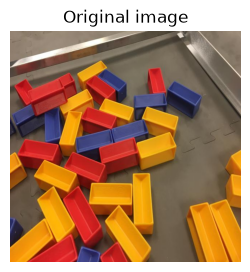

In [69]:
# Cell 2

kmeans_image_path = "dataset/img_01.jpg"

img_bgr = cv2.imread(kmeans_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

kmeans_img_luv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LUV)

print(img_rgb.shape)
print(kmeans_img_luv.shape)

plt.figure(figsize=(3,3))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()


### Cell 3: Chuẩn bị dữ liệu (Flatten image)
**Mục đích:** Biến đổi ảnh từ dạng ma trận 2D (chiều rộng x chiều cao) thành một mảng 1D chứa danh sách các pixel để đưa vào model.
**Cách hoạt động:** Sử dụng `.reshape(-1, 3)` để duỗi ma trận ảnh có kích thước `(H, W, 3)` thành `(H * W, 3)`. Thuật toán K-Means của scikit-learn yêu cầu đầu vào là một bảng dữ liệu 2 chiều với định dạng `(số lượng mẫu, số lượng đặc trưng)`. Ở đây, mỗi điểm ảnh (pixel) là một mẫu, và có 3 đặc trưng (3 kênh màu).

In [70]:
# Cell 3

kmeans_pixels_rgb = img_rgb.reshape(-1, 3)
kmeans_pixels_luv = kmeans_img_luv.reshape(-1, 3)

print(kmeans_pixels_rgb.shape)
print(kmeans_pixels_luv.shape)


(409600, 3)
(409600, 3)


### Cell 4: Khảo sát phân bố điểm ảnh (Trực quan hóa không gian L*u*)
**Mục đích:** Xem trước phân bố của các điểm ảnh trong không gian màu để hình dung các cụm màu trước khi phân loại.
**Cách hoạt động:** 
- Tách lấy kênh L và u từ dữ liệu L*u*v*.
- Nếu vẽ toàn bộ hàng triệu pixel thì biểu đồ sẽ rất nặng và rối. Do đó, code sử dụng `np.random.choice()` để lấy ngẫu nhiên 10,000 điểm ảnh đại diện.
- Cuối cùng dùng `plt.scatter()` để vẽ các điểm này, màu của mỗi chấm trên đồ thị được giữ nguyên là màu RGB thật của điểm ảnh đó.

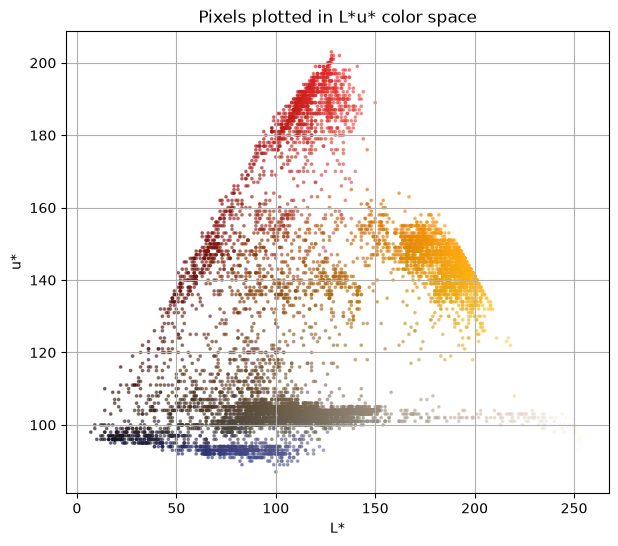

In [71]:
# Cell 4

kmeans_L = kmeans_pixels_luv[:, 0]
kmeans_u = kmeans_pixels_luv[:, 1]

# Lấy mẫu bớt pixel để vẽ cho nhẹ
kmeans_num_samples = 10000

kmeans_sample_indices = np.random.choice(
    len(kmeans_pixels_luv),
    size=kmeans_num_samples,
    replace=False
)

kmeans_sample_L = kmeans_L[kmeans_sample_indices]
kmeans_sample_u = kmeans_u[kmeans_sample_indices]
kmeans_sample_rgb = kmeans_pixels_rgb[kmeans_sample_indices] / 255.0

plt.figure(figsize=(7, 6))
plt.scatter(
    kmeans_sample_L,
    kmeans_sample_u,
    c=kmeans_sample_rgb,
    s=3,
    alpha=0.5
)

plt.xlabel("L*")
plt.ylabel("u*")
plt.title("Pixels plotted in L*u* color space")
plt.grid(True)
plt.show()


### Cell 5: Áp dụng thuật toán K-Means
**Mục đích:** Phân loại toàn bộ điểm ảnh vào `K` cụm (clusters) màu sắc khác nhau.
**Cách hoạt động:** 
- Khởi tạo model `KMeans` với số cụm `K = 6`.
- Gọi hàm `fit_predict(pixels_luv)`: Thuật toán sẽ tìm ra 6 tâm cụm đại diện cho 6 nhóm màu chính. Sau đó, nó gán nhãn (từ 0 đến 5) cho từng điểm ảnh tùy thuộc vào việc điểm ảnh đó gần tâm cụm nào nhất.

In [72]:
# Cell 5
# Implement K-Means models

from sklearn.cluster import KMeans

kmeans_k = 5

kmeans_model = KMeans(
    n_clusters=kmeans_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(kmeans_pixels_luv)
print(kmeans_labels[:6])


[2 2 2 2 2 2]


### Cell 6: So sánh không gian màu trước và sau khi Gom cụm (K-Means)
**Mục đích:** Đánh giá trực quan sự thay đổi phân bố và kết quả gom cụm của K-Means.
**Cách hoạt động:** 
- Vẽ 2 đồ thị cạnh nhau bằng `plt.subplot()`. 
- Đồ thị 1 hiển thị 10,000 điểm ảnh màu nguyên bản (đã làm ở Cell 4).
- Đồ thị 2 hiển thị 10,000 điểm ảnh đó nhưng được tô màu theo nhãn cụm (cluster ID) mà K-Means vừa dự đoán.
- `kmeans.cluster_centers_` chứa tọa độ của 6 tâm cụm. Các tâm này được vẽ lên đồ thị bằng dấu 'X' lớn màu đen để ta thấy rõ vị trí trung tâm của từng nhóm màu.

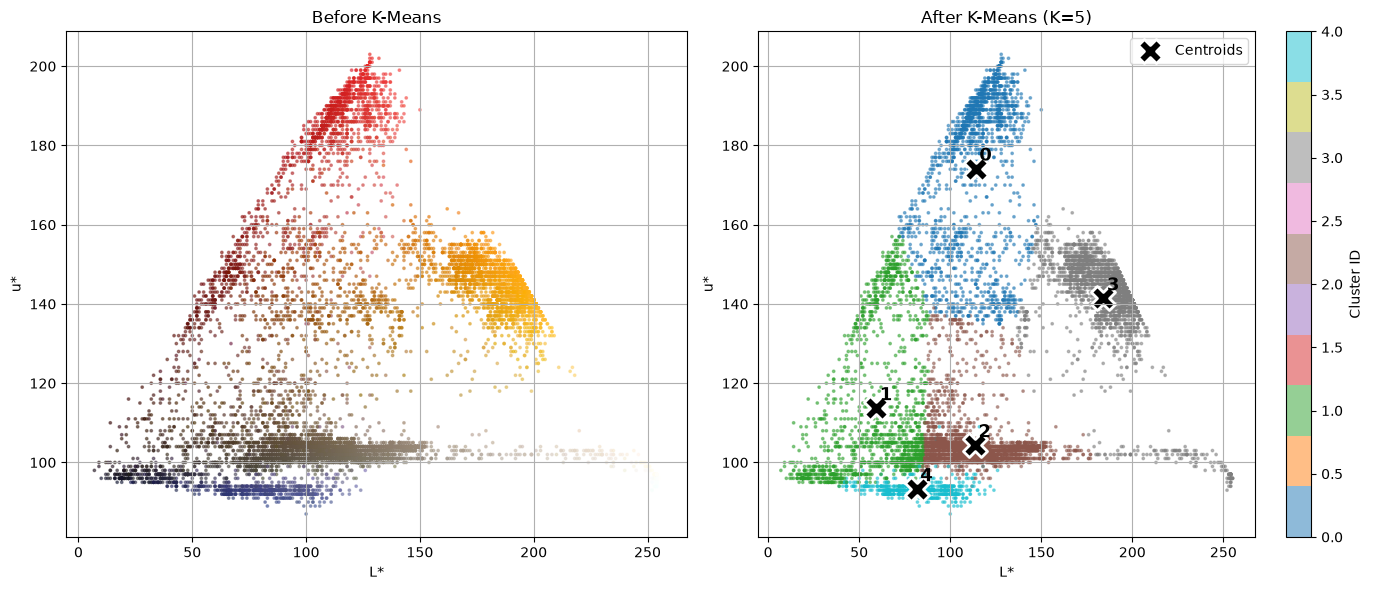

In [73]:
# Cell 6

kmeans_centers_luv = kmeans_model.cluster_centers_
kmeans_sample_labels = kmeans_labels[kmeans_sample_indices]

plt.figure(figsize=(14, 6))

# 1. Trước khi K-Means
plt.subplot(1, 2, 1)
plt.scatter(
    kmeans_sample_L,
    kmeans_sample_u,
    c=kmeans_sample_rgb,
    s=3,
    alpha=0.5
)
plt.xlabel("L*")
plt.ylabel("u*")
plt.title("Before K-Means")
plt.grid(True)

# 2. Sau khi K-Means
plt.subplot(1, 2, 2)
kmeans_scatter = plt.scatter(
    kmeans_sample_L,
    kmeans_sample_u,
    c=kmeans_sample_labels,
    s=3,
    alpha=0.5,
    cmap="tab10"
)

# Vẽ centroid của từng cluster
plt.scatter(
    kmeans_centers_luv[:, 0],      # L*
    kmeans_centers_luv[:, 1],      # u*
    c="black",
    s=300,
    marker="X",
    edgecolors="white",
    linewidths=2,
    label="Centroids"
)

# Ghi cluster id lên từng centroid
for kmeans_cluster_id, kmeans_center in enumerate(kmeans_centers_luv):
    plt.text(
        kmeans_center[0] + 2,
        kmeans_center[1] + 2,
        str(kmeans_cluster_id),
        fontsize=13,
        fontweight="bold",
        color="black"
    )

plt.xlabel("L*")
plt.ylabel("u*")
plt.title(f"After K-Means (K={kmeans_k})")
plt.grid(True)
plt.colorbar(kmeans_scatter, label="Cluster ID")
plt.legend()

plt.tight_layout()
plt.show()


### Cell 7: Tái tạo và hiển thị ảnh sau phân đoạn (Segmentation)
**Mục đích:** Thay thế màu của mỗi điểm ảnh bằng màu của tâm cụm tương ứng, tạo ra một bức ảnh bị giảm số lượng màu (chỉ còn K màu) - gọi là phân đoạn ảnh.
**Cách hoạt động:** 
- `centers[labels]`: Dùng mảng nhãn để tra cứu tọa độ màu trung tâm. Thay vì dùng màu gốc, mỗi pixel bây giờ mang màu của tâm cụm.
- `.reshape(img_luv.shape)`: Cuộn lại mảng 1D thành mảng ảnh 3D `(H, W, 3)` ban đầu.
- Chuyển không gian màu ngược lại từ L*u*v* về RGB để có thể hiển thị ảnh ra màn hình bằng matplotlib. Bức ảnh mới sẽ trông giống như tranh vẽ mảng màu (Posterization).

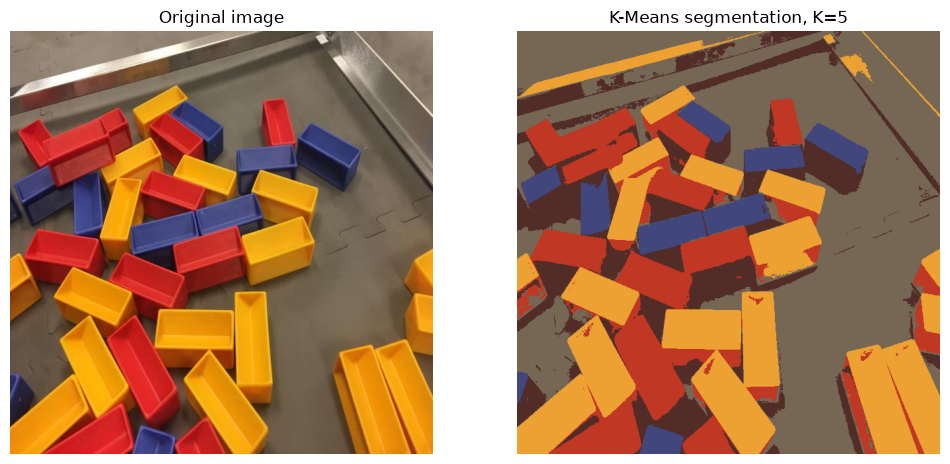

In [74]:
# Cell 7

kmeans_centers_luv = kmeans_model.cluster_centers_

kmeans_segmented_luv = kmeans_centers_luv[kmeans_labels]
kmeans_segmented_luv = kmeans_segmented_luv.reshape(kmeans_img_luv.shape).astype(np.uint8)

kmeans_segmented_rgb = cv2.cvtColor(kmeans_segmented_luv, cv2.COLOR_LUV2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(kmeans_segmented_rgb)
plt.axis("off")
plt.title(f"K-Means segmentation, K={kmeans_k}")

plt.show()


# Gaussian Mixture Model (GMM)
**Tham khảo:** [scikit-learn GMM documentation](https://scikit-learn.org/stable/modules/mixture.html)

**Keywords:**
- The Means
- The Covariance
- The Weight

### 1. Kiến thức cơ bản về GMM
**Gaussian Mixture Model (GMM)** là một mô hình học máy theo hướng xác suất được sử dụng để gom cụm dữ liệu (Clustering). Khác với các thuật toán phân tách khoảng cách thông thường, GMM giả định rằng tất cả các điểm dữ liệu được sinh ra từ sự pha trộn (mixture) của $K$ phân bố Gaussian (phân bố chuẩn) ẩn.

### 2. Sự vượt trội của GMM so với K-Means
- **Phân cụm mềm (Soft Clustering):** 
  - K-Means thực hiện *Hard Clustering*: Một điểm ảnh chỉ được gán tuyệt đối vào 1 cụm duy nhất.
  - GMM thực hiện *Soft Clustering*: GMM trả về **xác suất** (từ 0.0 đến 1.0) cho thấy mức độ tự tin một điểm thuộc về cụm nào. (Ví dụ: 90% thuộc cụm A, 10% thuộc cụm B).
- **Hình dáng cụm linh hoạt (Covariance & Cluster Shape):**
  - K-Means mặc định các cụm có hình cầu và kích thước tương đương nhau.
  - GMM sử dụng Ma trận hiệp phương sai (**Covariance Matrix**) cho phép từng cụm được kéo dài, dẹt lại, xoay nghiêng hoặc to/nhỏ tùy ý dưới dạng hình elip để bao quát chính xác hình thù của dữ liệu thật.

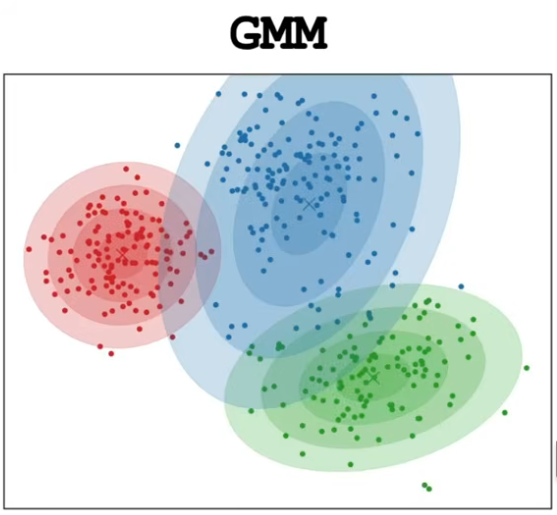


### GMM Cell 1: Import mô hình GMM
**Mục đích:** Nhập thư viện `GaussianMixture` từ scikit-learn để chuẩn bị cho việc phân cụm xác suất (GMM).
**Cách hoạt động:** GMM (Gaussian Mixture Model) là mô hình xác suất giả định rằng dữ liệu được sinh ra từ sự pha trộn của K phân bố Gaussian (phân bố chuẩn). GMM mềm dẻo hơn K-Means ở chỗ nó mô tả cụm bằng cả phương sai (độ phình rộng/elip) và tâm cụm.

In [75]:
from sklearn.mixture import GaussianMixture

### GMM Cell 2: Đọc ảnh và xem trước
**Mục đích:** Đọc hình ảnh đầu vào (`img_01.jpg`) và hiển thị xem trước.
**Cách hoạt động:** Giống như trong phần K-Means, đọc ảnh BGR và đổi sang RGB bằng OpenCV để hiển thị bằng matplotlib.

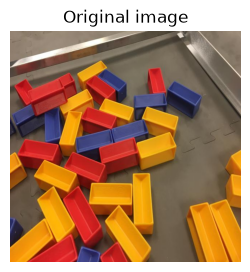

In [76]:
gmm_image_path = "dataset/img_01.jpg"   # đổi path nếu chạy trên máy/Colab

img_bgr = cv2.imread(gmm_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(3, 3))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()


### GMM Cell 3: Chuẩn bị dữ liệu và chuyển đổi không gian màu
**Mục đích:** Đưa ảnh về dạng vector pixel (1D) và sử dụng không gian màu L*u*v* tối ưu.
**Cách hoạt động:** Dùng hàm `reshape(-1, 3)` biến ma trận ảnh thành mảng danh sách điểm ảnh để tương thích với input `(n_samples, n_features)` của mô hình học máy GMM.

In [77]:
gmm_img_luv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LUV)

gmm_pixels_rgb = img_rgb.reshape(-1, 3)
gmm_pixels_luv = gmm_img_luv.reshape(-1, 3)

print("Image shape:", img_rgb.shape)
print("Pixels shape:", gmm_pixels_luv.shape)


Image shape: (640, 640, 3)
Pixels shape: (409600, 3)


### GMM Cell 4: Khởi tạo và Huấn luyện (Fit) mô hình GMM
**Mục đích:** Tạo mô hình GMM với $K=6$ và cho nó 'học' phân bố dữ liệu từ các điểm ảnh.
**Cách hoạt động:** 
- `covariance_type='full'`: Cho phép mỗi cụm có hình dạng elip độc lập (xoay, kéo dài khác nhau).
- `init_params='kmeans'`: Khởi tạo tâm cụm ban đầu bằng K-Means giúp thuật toán EM của GMM hội tụ nhanh hơn.
- `fit()`: Chạy thuật toán Expectation-Maximization (EM) để tìm Means (kỳ vọng), Covariances (ma trận hiệp phương sai) và Weights (tỷ lệ) của 6 phân bố.

In [78]:
gmm_k = 5

gmm_model = GaussianMixture(
    n_components=gmm_k,
    covariance_type="full",
    init_params="kmeans",
    random_state=42,
    max_iter=100
)

gmm_model.fit(gmm_pixels_luv)


,"n_components n_components: int, default=1The number of mixture components.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


### GMM Cell 5: Phân cụm (Hard Clustering)
**Mục đích:** Lấy kết quả gán nhãn cụm cho từng điểm ảnh.
**Cách hoạt động:** Hàm `predict()` tính toán xác suất mỗi điểm ảnh thuộc về từng cụm và chọn ra cụm có xác suất lớn nhất làm nhãn duy nhất (Hard Clustering).

In [79]:
gmm_labels = gmm_model.predict(gmm_pixels_luv)

print(gmm_labels.shape)
print(gmm_labels[:20])


(409600,)
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### GMM Cell 6: Biểu diễn bản đồ nhãn (Label Map)
**Mục đích:** Hiển thị vị trí phân bố của 6 cụm ngay trên không gian 2D của bức ảnh.
**Cách hoạt động:** Lấy mảng `labels` 1D cuộn lại (`reshape`) theo kích thước rộng x cao của ảnh. Mỗi vùng nhãn sẽ được hiển thị bằng một màu của colormap `tab10`.

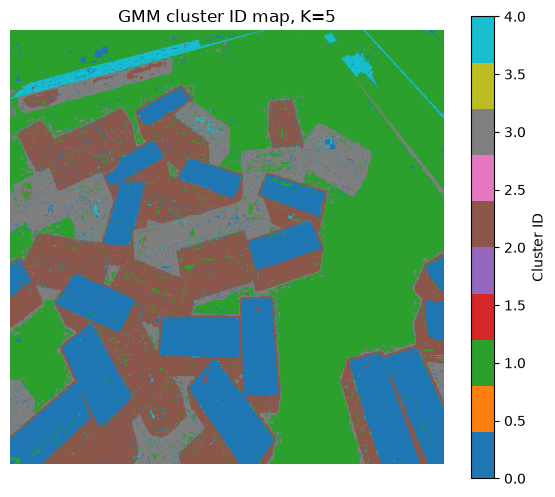

In [80]:
gmm_label_img = gmm_labels.reshape(img_rgb.shape[:2])

plt.figure(figsize=(7, 6))
plt.imshow(gmm_label_img, cmap="tab10")
plt.axis("off")
plt.title(f"GMM cluster ID map, K={gmm_k}")
plt.colorbar(label="Cluster ID")
plt.show()


### GMM Cell 7: Tính toán ma trận Xác suất (Soft Clustering)
**Mục đích:** Tìm ra mức độ tự tin (xác suất từ 0 đến 1) chứng tỏ một pixel thuộc về từng cụm cụ thể.
**Cách hoạt động:** Sự khác biệt cốt lõi của GMM là nó phân cụm mềm (Soft Clustering). Hàm `predict_proba()` không chỉ gán 1 nhãn, mà trả về xác suất điểm đó thuộc về cụm 0, cụm 1,... đến cụm K. Trả về ma trận `(N, K)`.

In [81]:
gmm_probs = gmm_model.predict_proba(gmm_pixels_luv)

print(gmm_probs.shape)
print(gmm_probs[:5])


(409600, 5)
[[3.77571536e-09 9.99273759e-01 4.10970657e-19 6.49902181e-05
  6.61247339e-04]
 [3.77571536e-09 9.99273759e-01 4.10970657e-19 6.49902181e-05
  6.61247339e-04]
 [3.77571536e-09 9.99273759e-01 4.10970657e-19 6.49902181e-05
  6.61247339e-04]
 [1.28253904e-17 9.98845293e-01 2.49159424e-19 6.49623517e-05
  1.08974509e-03]
 [1.28253904e-17 9.98845293e-01 2.49159424e-19 6.49623517e-05
  1.08974509e-03]]


### GMM Cell 8: Hiển thị bản đồ độ tự tin (Probability map) của một cụm
**Mục đích:** Trực quan hóa xác suất một điểm ảnh thuộc về một cụm cụ thể (Ví dụ: cụm 5).
**Cách hoạt động:** Lấy cột thứ 5 của ma trận xác suất `probs` và hiển thị bằng ảnh đa độ xám (grayscale). Điểm ảnh nào càng sáng (càng gần 1.0) thì GMM càng chắc chắn điểm đó thuộc về cụm 5.

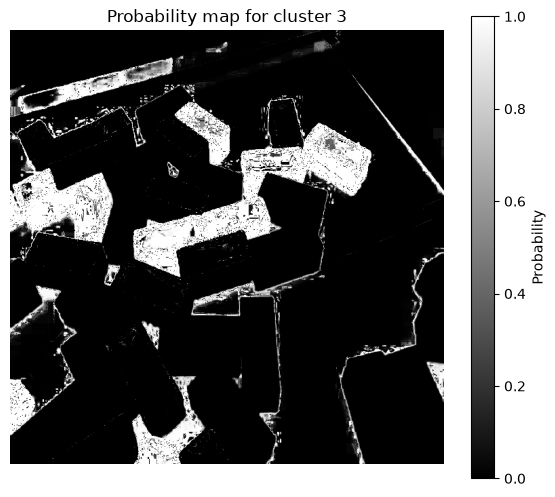

In [82]:
gmm_target_cluster = 3

gmm_prob_img = gmm_probs[:, gmm_target_cluster].reshape(img_rgb.shape[:2])

plt.figure(figsize=(7, 6))
plt.imshow(gmm_prob_img, cmap="gray")
plt.axis("off")
plt.title(f"Probability map for cluster {gmm_target_cluster}")
plt.colorbar(label="Probability")
plt.show()


### GMM Cell 9: Tái tạo và so sánh ảnh (Image Segmentation)
**Mục đích:** Hiển thị kết quả giảm số lượng màu xuống còn $K$ màu (Phân đoạn ảnh).
**Cách hoạt động:** Lấy điểm trung bình `means_` làm đại diện cho cụm. Thay thế mọi pixel trong cụm đó bằng màu của Mean, chuyển ngược lại về RGB và in so sánh với ảnh gốc.

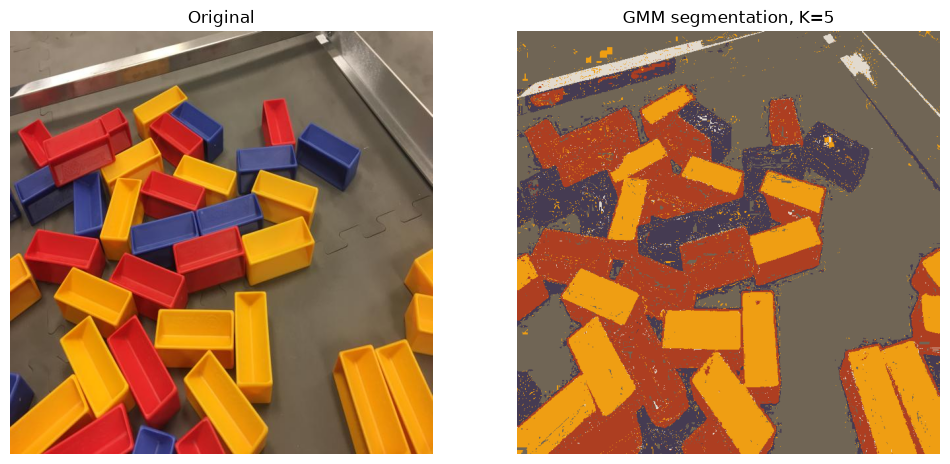

In [83]:
gmm_means_luv = gmm_model.means_

gmm_segmented_luv = gmm_means_luv[gmm_labels]
gmm_segmented_luv = gmm_segmented_luv.reshape(gmm_img_luv.shape).astype(np.uint8)

gmm_segmented_rgb = cv2.cvtColor(gmm_segmented_luv, cv2.COLOR_LUV2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(gmm_segmented_rgb)
plt.axis("off")
plt.title(f"GMM segmentation, K={gmm_k}")

plt.show()


### GMM Cell 10: So sánh phân bố L*u* trước và sau GMM
**Mục đích:** Xem xét trực quan các cụm màu và vị trí tọa độ của GMM Means trong không gian màu L*u*.
**Cách hoạt động:** Trích xuất ngẫu nhiên 10.000 pixel, vẽ đồ thị màu gốc (trái) và đồ thị gán nhãn GMM (phải) kèm theo biểu tượng 'X' đen là tọa độ trung tâm Means của GMM.

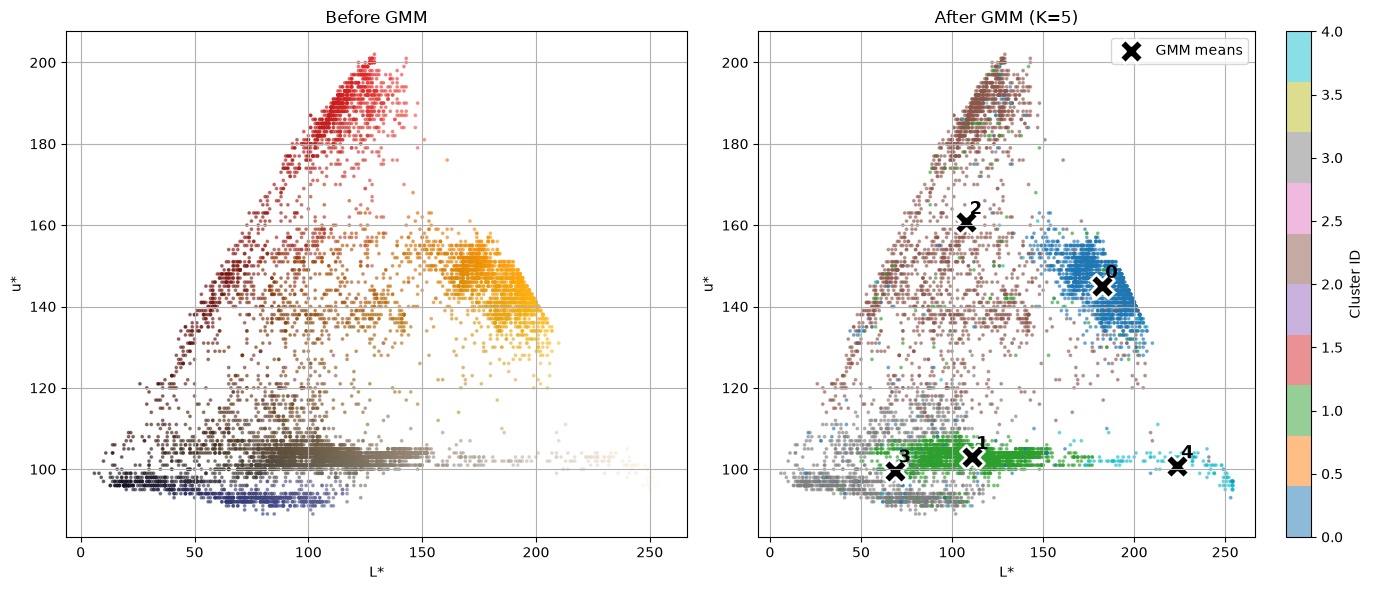

In [84]:
gmm_num_samples = 10000

gmm_sample_indices = np.random.choice(
    len(gmm_pixels_luv),
    size=min(gmm_num_samples, len(gmm_pixels_luv)),
    replace=False
)

gmm_sample_L = gmm_pixels_luv[gmm_sample_indices, 0]
gmm_sample_u = gmm_pixels_luv[gmm_sample_indices, 1]
gmm_sample_labels = gmm_labels[gmm_sample_indices]
gmm_sample_rgb = gmm_pixels_rgb[gmm_sample_indices] / 255.0

gmm_means_luv = gmm_model.means_

plt.figure(figsize=(14, 6))

# 1. Trước khi GMM
plt.subplot(1, 2, 1)
plt.scatter(
    gmm_sample_L,
    gmm_sample_u,
    c=gmm_sample_rgb,
    s=3,
    alpha=0.5
)
plt.xlabel("L*")
plt.ylabel("u*")
plt.title("Before GMM")
plt.grid(True)

# 2. Sau khi GMM
plt.subplot(1, 2, 2)
gmm_scatter = plt.scatter(
    gmm_sample_L,
    gmm_sample_u,
    c=gmm_sample_labels,
    s=3,
    alpha=0.5,
    cmap="tab10"
)

plt.scatter(
    gmm_means_luv[:, 0],
    gmm_means_luv[:, 1],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidths=2,
    label="GMM means"
)

for gmm_cluster_id, gmm_mean in enumerate(gmm_means_luv):
    plt.text(
        gmm_mean[0] + 2,
        gmm_mean[1] + 2,
        str(gmm_cluster_id),
        fontsize=13,
        fontweight="bold",
        color="black"
    )

plt.xlabel("L*")
plt.ylabel("u*")
plt.title(f"After GMM (K={gmm_k})")
plt.grid(True)
plt.colorbar(gmm_scatter, label="Cluster ID")
plt.legend()

plt.tight_layout()
plt.show()


### GMM Cell 11: Khảo sát các tham số Toán học của GMM
**Mục đích:** In ra các thông số đã học được của mô hình GMM để hiểu rõ hơn bản chất của dữ liệu.
**Cách hoạt động:**
- `gmm.means_`: Trung bình màu (tọa độ trung tâm) của mỗi cụm.
- `gmm.weights_`: Tỉ lệ phần trăm tổng số điểm ảnh rơi vào từng cụm.
- `gmm.covariances_`: Ma trận hiệp phương sai mô tả sự phân tán, kích thước và góc xoay của phân bố hình elip.

In [85]:
print("GMM means:")
for gmm_cluster_id, gmm_mean in enumerate(gmm_model.means_):
    print(f"Cluster {gmm_cluster_id} mean Luv: {gmm_mean}")

print("\nGMM weights:")
for gmm_cluster_id, gmm_weight in enumerate(gmm_model.weights_):
    print(f"Cluster {gmm_cluster_id} weight: {gmm_weight:.4f}")

print("Covariance: \n")
print(f"{gmm_model.covariances_.shape}")
print(gmm_model.covariances_[0])


GMM means:
Cluster 0 mean Luv: [182.14128729 145.03626516 204.5541901 ]
Cluster 1 mean Luv: [111.21723519 102.94317774 149.97016523]
Cluster 2 mean Luv: [107.64349525 160.74881036 165.56274907]
Cluster 3 mean Luv: [ 68.51969771  99.68219524 121.16226547]
Cluster 4 mean Luv: [223.77513562 100.72249373 146.75296099]

GMM weights:
Cluster 0 weight: 0.1986
Cluster 1 weight: 0.3911
Cluster 2 weight: 0.2505
Cluster 3 weight: 0.1445
Cluster 4 weight: 0.0154
Covariance: 

(5, 3, 3)
[[162.0443307  -47.63987508  70.46356923]
 [-47.63987508  34.15801095 -23.13586572]
 [ 70.46356923 -23.13586572  31.76817253]]


### GMM Cell 12: Ứng dụng - Tìm viền và vẽ Bounding Box cho 1 cụm
**Mục đích:** Phát hiện ra ranh giới vật lý của các vùng pixel thuộc về cụm 5 trên bức ảnh và đóng khung Bounding box chúng.
**Cách hoạt động:**
- `(label_img == target_cluster)`: Tạo ảnh nhị phân (mask).
- `cv2.findContours()`: Tìm các đường bao quanh những vùng trắng trên mask.
- Dùng `cv2.boundingRect()` để vẽ hình chữ nhật bao quanh vùng contour. Thêm điều kiện `area < 300` để lọc bỏ đi các đốm nhiễu li ti.

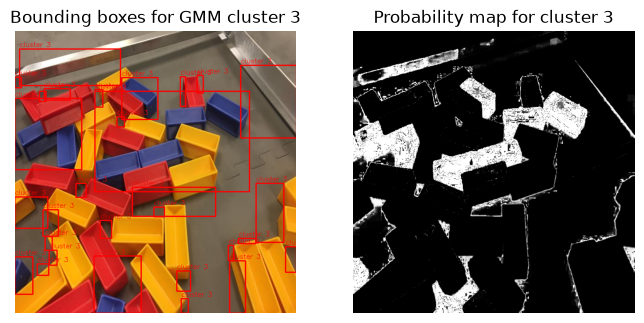

In [86]:
gmm_target_cluster = 3

gmm_cluster_mask = (gmm_label_img == gmm_target_cluster).astype(np.uint8) * 255

gmm_contours, _ = cv2.findContours(
    gmm_cluster_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

gmm_bbox_img = img_rgb.copy()

for gmm_contour in gmm_contours:
    gmm_x, gmm_y, gmm_w, gmm_h = cv2.boundingRect(gmm_contour)

    gmm_area = gmm_w * gmm_h
    if gmm_area < 300:
        continue

    cv2.rectangle(
        gmm_bbox_img,
        (gmm_x, gmm_y),
        (gmm_x + gmm_w, gmm_y + gmm_h),
        (255, 0, 0),
        2
    )

    cv2.putText(
        gmm_bbox_img,
        f"cluster {gmm_target_cluster}",
        (gmm_x, gmm_y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(8, 8))

plt.subplot(1,2,1)
plt.imshow(gmm_bbox_img)
plt.axis("off")
plt.title(f"Bounding boxes for GMM cluster {gmm_target_cluster}")

plt.subplot(1,2,2)
plt.imshow(gmm_prob_img, cmap="gray")
plt.axis("off")
plt.title(f"Probability map for cluster {gmm_target_cluster}")
plt.show()


# Mean Shift Clustering
**Tham khảo:** [scikit-learn Mean Shift](https://scikit-learn.org/stable/modules/clustering.html#mean-shift)

### 1. Kiến thức cơ bản về Mean Shift
**Mean Shift** là một thuật toán phân cụm phi tham số (non-parametric), dựa trên mật độ (density-based). Khác với K-Means hay GMM, Mean Shift không yêu cầu người dùng phải chỉ định trước số lượng cụm $K$. Thuật toán sẽ tự động tìm ra số lượng cụm tối ưu dựa vào mật độ phân bố dữ liệu trong không gian.

### 2. Nguyên lý hoạt động (Sliding Window & KDE)
Mean Shift hoạt động giống như một quá trình leo đồi tìm đỉnh mật độ (Mode / Peak):
1. **Đặt cửa sổ:** Tại mỗi điểm dữ liệu, đặt một cửa sổ tìm kiếm (hình cầu/tròn) với bán kính gọi là **Bandwidth**.
2. **Tính trọng tâm:** Tính toán trọng tâm (mean) của tất cả các điểm dữ liệu lọt vào bên trong cửa sổ đó.
3. **Dịch chuyển (Shift):** Dịch chuyển tâm của cửa sổ tới vị trí trọng tâm vừa tính được.
4. **Hội tụ:** Lặp lại bước 2 và 3 cho đến khi cửa sổ không còn dịch chuyển nữa (đạt tới đỉnh mật độ cao nhất - Mode).
5. **Hợp nhất:** Các cửa sổ có điểm hội tụ nằm rất gần nhau sẽ được gộp chung thành một cụm duy nhất.

### 3. So sánh với K-Means và GMM
- **Ưu điểm vượt trội:** Tự động phát hiện số lượng cụm $K$. Có thể tìm được các cụm có hình thù bất kỳ dựa theo mật độ thực tế chứ không bị gò bó vào hình cầu (K-Means) hay elip (GMM).
- **Nhược điểm:** Độ phức tạp tính toán lớn ($O(N^2)$), chạy khá chậm nếu tập dữ liệu có hàng triệu điểm. Nhạy cảm với việc chọn tham số bán kính `bandwidth`.


# **Part 1:** Simulating fake data for first insign

### Mean Shift Cell 1: Import các thư viện và mô đun cần thiết
**Mục đích:** Khởi tạo môi trường tính toán số học, thao tác ma trận và vẽ đồ thị cho thuật toán Mean Shift.
**Cách hoạt động:** Nhập `numpy` để thao tác tính toán khoảng cách vector; `matplotlib` cùng đối tượng `Circle` để trực quan hóa các đường quỹ đạo dịch chuyển và vòng tròn bán kính; `MeanShift` từ thư viện `scikit-learn` để đối chiếu với thuật toán tự cài đặt.

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
from matplotlib.patches import Circle

### Mean Shift Demo: Tạo dữ liệu giả lập (Data Simulation)
**Mục đích:** Tạo ra các cụm điểm dữ liệu ngẫu nhiên trên mặt phẳng 2D (dùng `make_blobs`) nhằm kiểm chứng hoạt động của thuật toán Mean Shift tự cài đặt.

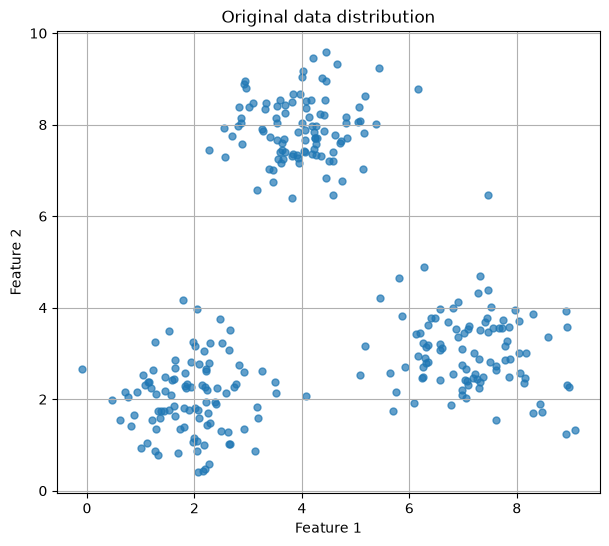

In [88]:
# Data simulation
# Purpose: Understand how Mean Shift works.

meanshift_demo_X, meanshift_demo_true_labels = make_blobs(
    n_samples=300,
    centers=[
        [2, 2],
        [7, 3],
        [4, 8]
    ],
    cluster_std=[
        0.8,
        0.9,
        0.7
    ],
    random_state=42
)

plt.figure(figsize=(7, 6))
plt.scatter(meanshift_demo_X[:, 0], meanshift_demo_X[:, 1], s=25, alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original data distribution")
plt.grid(True)
plt.show()


### Mean Shift Cell 4: Cài đặt thủ công thuật toán Mean Shift
**Mục đích:** Xây dựng hàm `manual_mean_shift` mô phỏng chính xác từng bước leo đồi của các cửa sổ tìm kiếm.
**Cách hoạt động:** Tại mỗi điểm xuất phát, tìm các láng giềng trong bán kính `bandwidth`, tính trung bình tọa độ (`neighbors.mean()`), dịch chuyển tâm đến đó và ghi lại quỹ đạo (`trajectory`) cho tới khi dừng.

In [89]:
def manual_mean_shift_demo(data_points, bandwidth, max_iter=100, tol=1e-3):
    demo_trajectories = []
    demo_final_points = []

    for start_point in data_points:
        current_point = start_point.copy()
        point_trajectory = [current_point.copy()]

        for _ in range(max_iter):
            distances = np.linalg.norm(data_points - current_point, axis=1)

            neighbors = data_points[distances <= bandwidth]

            if len(neighbors) == 0:
                break

            new_current_point = neighbors.mean(axis=0)

            shift_distance = np.linalg.norm(new_current_point - current_point)

            point_trajectory.append(new_current_point.copy())

            current_point = new_current_point

            if shift_distance < tol:
                break

        demo_trajectories.append(np.array(point_trajectory))
        demo_final_points.append(current_point)

    return np.array(demo_final_points), demo_trajectories


### Mean Shift Demo: Thực thi thuật toán tự viết trên dữ liệu giả lập
**Mục đích:** Chạy hàm `manual_mean_shift_demo()` lên bộ dữ liệu giả lập với bán kính tìm kiếm `bandwidth = 1.8`.

In [90]:
meanshift_demo_bandwidth = 1.8

meanshift_demo_final_points, meanshift_demo_trajectories = manual_mean_shift_demo(
    meanshift_demo_X,
    bandwidth=meanshift_demo_bandwidth,
    max_iter=100,
    tol=1e-3
)

print("Number of original points:", len(meanshift_demo_X))
print("Number of final converged points:", len(meanshift_demo_final_points))


Number of original points: 300
Number of final converged points: 300


### Mean Shift Cell 6: Hàm hợp nhất các đỉnh mật độ (Merge Modes)
**Mục đích:** Gộp các cửa sổ có điểm dừng hội tụ nằm sát cạnh nhau thành một đỉnh (Mode) duy nhất.

In [91]:
def merge_mean_shift_demo_modes(shifted_points, merge_distance):
    demo_modes = []
    demo_labels = np.full(len(shifted_points), fill_value=-1)

    for point_id, shifted_point in enumerate(shifted_points):
        assigned = False

        for mode_id, demo_mode in enumerate(demo_modes):
            mode_distance = np.linalg.norm(shifted_point - demo_mode)

            if mode_distance <= merge_distance:
                demo_labels[point_id] = mode_id

                # cập nhật mode bằng trung bình đơn giản
                demo_modes[mode_id] = (demo_mode + shifted_point) / 2

                assigned = True
                break

        if not assigned:
            demo_modes.append(shifted_point.copy())
            demo_labels[point_id] = len(demo_modes) - 1

    return np.array(demo_modes), demo_labels


### Mean Shift Cell 7: Thực thi hợp nhất tâm cụm
**Mục đích:** Gộp tâm cụm với khoảng cách bằng nửa bandwidth, qua đó tự động phát hiện ra số lượng cụm tối ưu.

In [92]:
meanshift_demo_merge_distance = meanshift_demo_bandwidth / 2

meanshift_demo_modes, meanshift_demo_labels = merge_mean_shift_demo_modes(
    meanshift_demo_final_points,
    merge_distance=meanshift_demo_merge_distance
)

print("Number of modes / clusters:", len(meanshift_demo_modes))

for mode_id, meanshift_demo_mode in enumerate(meanshift_demo_modes):
    print(f"Mode {mode_id}: {meanshift_demo_mode}")


Number of modes / clusters: 3
Mode 0: [1.92234074 1.96005386]
Mode 1: [3.9311188  7.88927011]
Mode 2: [7.0963927  3.04759312]


### Mean Shift Demo: Trực quan hóa Quỹ đạo leo đồi trên dữ liệu giả lập
**Mục đích:** Vẽ biểu đồ scatter hiển thị các điểm dữ liệu giả lập, đường đi quỹ đạo (`trajectories`) hút về các đỉnh hội tụ và tâm cụm (`modes`).

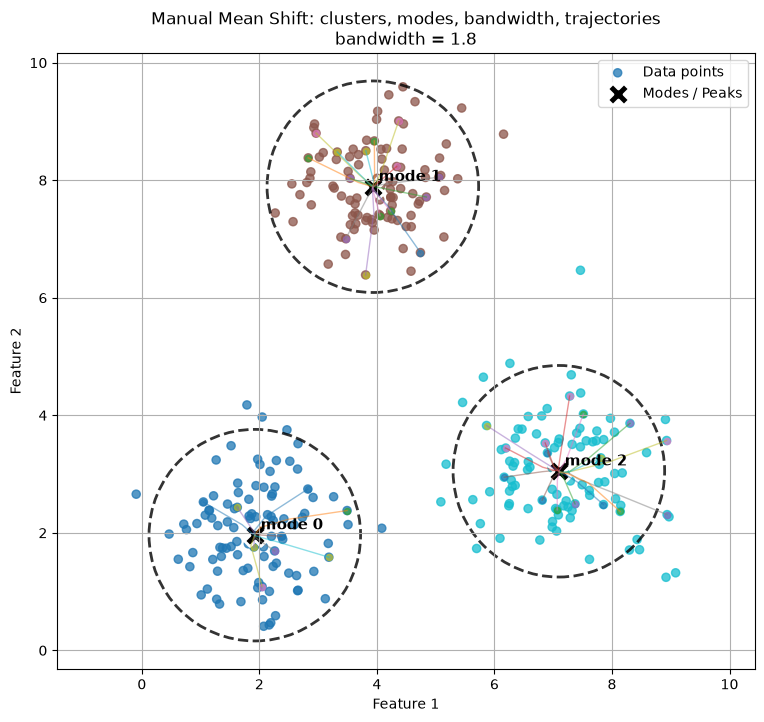

In [93]:
plt.figure(figsize=(9, 8))

# Vẽ điểm dữ liệu theo cluster
plt.scatter(
    meanshift_demo_X[:, 0],
    meanshift_demo_X[:, 1],
    c=meanshift_demo_labels,
    cmap="tab10",
    s=35,
    alpha=0.75,
    label="Data points"
)

# Vẽ trajectory cho một số điểm để đỡ rối
meanshift_demo_num_trajectories_to_show = 40
meanshift_demo_trajectory_indices = np.random.choice(
    len(meanshift_demo_trajectories),
    size=meanshift_demo_num_trajectories_to_show,
    replace=False
)

for meanshift_demo_idx in meanshift_demo_trajectory_indices:
    meanshift_demo_traj = meanshift_demo_trajectories[meanshift_demo_idx]

    plt.plot(
        meanshift_demo_traj[:, 0],
        meanshift_demo_traj[:, 1],
        linewidth=1,
        alpha=0.5
    )

    plt.scatter(
        meanshift_demo_traj[0, 0],
        meanshift_demo_traj[0, 1],
        s=20,
        marker="o",
        alpha=0.6
    )

    plt.scatter(
        meanshift_demo_traj[-1, 0],
        meanshift_demo_traj[-1, 1],
        s=30,
        marker="x",
        alpha=0.8
    )

# Vẽ mode / peak
plt.scatter(
    meanshift_demo_modes[:, 0],
    meanshift_demo_modes[:, 1],
    c="black",
    s=250,
    marker="X",
    edgecolors="white",
    linewidths=2,
    label="Modes / Peaks"
)

# Vẽ bandwidth quanh mỗi mode
for mode_id, meanshift_demo_mode in enumerate(meanshift_demo_modes):
    meanshift_demo_circle = Circle(
        (meanshift_demo_mode[0], meanshift_demo_mode[1]),
        radius=meanshift_demo_bandwidth,
        fill=False,
        linestyle="--",
        linewidth=2,
        alpha=0.8
    )

    plt.gca().add_patch(meanshift_demo_circle)

    plt.text(
        meanshift_demo_mode[0] + 0.1,
        meanshift_demo_mode[1] + 0.1,
        f"mode {mode_id}",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Manual Mean Shift: clusters, modes, bandwidth, trajectories\nbandwidth = {meanshift_demo_bandwidth}")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


### Mean Shift Demo: Đối chiếu bằng thư viện Scikit-Learn
**Mục đích:** Khởi tạo và chạy mô hình `MeanShift` chuẩn từ thư viện `sklearn` lên cùng bộ dữ liệu giả lập để xác minh tính chính xác của hàm tự cài đặt.

In [94]:
meanshift_demo_model = MeanShift(
    bandwidth=meanshift_demo_bandwidth,
    bin_seeding=False
)

meanshift_demo_model.fit(meanshift_demo_X)

meanshift_demo_sklearn_labels = meanshift_demo_model.labels_
meanshift_demo_sklearn_modes = meanshift_demo_model.cluster_centers_

print("Number of clusters:", len(meanshift_demo_sklearn_modes))
print("Modes:")
print(meanshift_demo_sklearn_modes)


Number of clusters: 3
Modes:
[[3.9311188  7.88927011]
 [1.92234074 1.96005386]
 [7.10917121 3.03333413]]


### Mean Shift Demo: Trực quan hóa kết quả của Scikit-Learn
**Mục đích:** Hiển thị kết quả gom cụm và vị trí tâm cụm do thư viện Scikit-Learn dự đoán để đối chiếu với đồ thị thủ công.

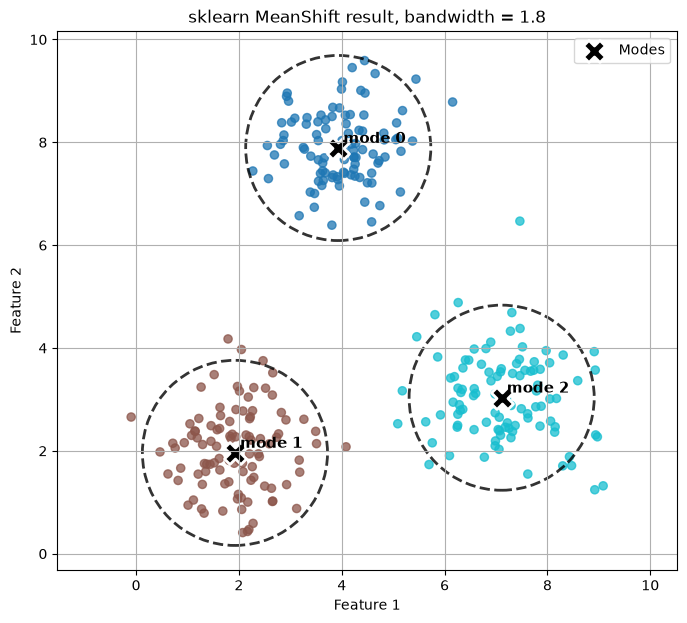

In [95]:
plt.figure(figsize=(8, 7))

plt.scatter(
    meanshift_demo_X[:, 0],
    meanshift_demo_X[:, 1],
    c=meanshift_demo_sklearn_labels,
    cmap="tab10",
    s=35,
    alpha=0.75
)

plt.scatter(
    meanshift_demo_sklearn_modes[:, 0],
    meanshift_demo_sklearn_modes[:, 1],
    c="black",
    s=250,
    marker="X",
    edgecolors="white",
    linewidths=2,
    label="Modes"
)

for mode_id, meanshift_demo_sklearn_mode in enumerate(meanshift_demo_sklearn_modes):
    meanshift_demo_circle = Circle(
        (meanshift_demo_sklearn_mode[0], meanshift_demo_sklearn_mode[1]),
        radius=meanshift_demo_bandwidth,
        fill=False,
        linestyle="--",
        linewidth=2,
        alpha=0.8
    )
    plt.gca().add_patch(meanshift_demo_circle)

    plt.text(
        meanshift_demo_sklearn_mode[0] + 0.1,
        meanshift_demo_sklearn_mode[1] + 0.1,
        f"mode {mode_id}",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"sklearn MeanShift result, bandwidth = {meanshift_demo_bandwidth}")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


### Mean Shift Demo: Khảo sát ảnh hưởng của tham số Bandwidth
**Mục đích:** Hiển thị so sánh trực quan sự thay đổi số lượng cụm khi điều chỉnh bán kính `bandwidth` từ nhỏ (chia vụn cụm) đến lớn (gộp cụm).

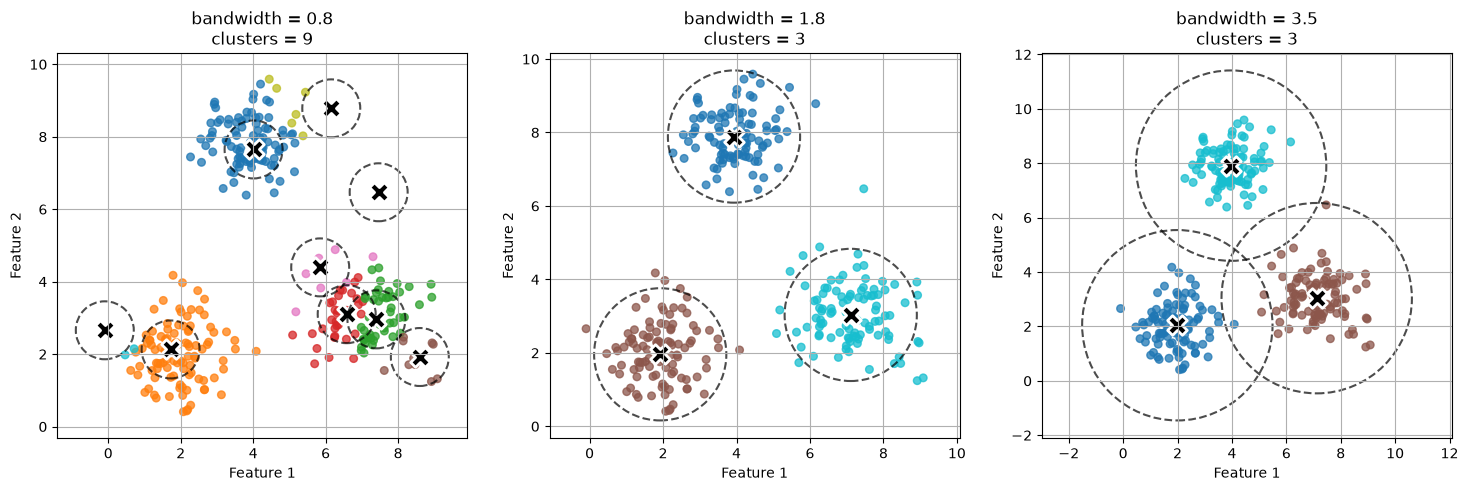

In [96]:
meanshift_demo_bandwidth_values = [0.8, 1.8, 3.5]

plt.figure(figsize=(18, 5))

for bandwidth_id, meanshift_demo_bw in enumerate(meanshift_demo_bandwidth_values):
    meanshift_demo_model_bw = MeanShift(
        bandwidth=meanshift_demo_bw,
        bin_seeding=False
    )

    meanshift_demo_model_bw.fit(meanshift_demo_X)

    meanshift_demo_labels_bw = meanshift_demo_model_bw.labels_
    meanshift_demo_modes_bw = meanshift_demo_model_bw.cluster_centers_

    plt.subplot(1, 3, bandwidth_id + 1)

    plt.scatter(
        meanshift_demo_X[:, 0],
        meanshift_demo_X[:, 1],
        c=meanshift_demo_labels_bw,
        cmap="tab10",
        s=30,
        alpha=0.75
    )

    plt.scatter(
        meanshift_demo_modes_bw[:, 0],
        meanshift_demo_modes_bw[:, 1],
        c="black",
        s=200,
        marker="X",
        edgecolors="white",
        linewidths=2
    )

    for meanshift_demo_mode_bw in meanshift_demo_modes_bw:
        meanshift_demo_circle = Circle(
            (meanshift_demo_mode_bw[0], meanshift_demo_mode_bw[1]),
            radius=meanshift_demo_bw,
            fill=False,
            linestyle="--",
            linewidth=1.5,
            alpha=0.7
        )
        plt.gca().add_patch(meanshift_demo_circle)

    plt.title(f"bandwidth = {meanshift_demo_bw}\nclusters = {len(meanshift_demo_modes_bw)}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.axis("equal")

plt.show()


### Mean Shift Demo: Tự động ước lượng Bandwidth tối ưu
**Mục đích:** Sử dụng hàm `estimate_bandwidth()` của thư viện Scikit-Learn để tự động tính toán bán kính tìm kiếm tối ưu dựa trên phân bố láng giềng thực tế.

In [97]:
meanshift_demo_estimated_bw = estimate_bandwidth(
    meanshift_demo_X,
    quantile=0.2,
    n_samples=len(meanshift_demo_X)
)

print("Estimated bandwidth:", meanshift_demo_estimated_bw)


Estimated bandwidth: 1.46715405627511


### Mean Shift Demo: Chạy mô hình với Bandwidth tự ước lượng
**Mục đích:** Huấn luyện mô hình Mean Shift và vẽ biểu đồ phân cụm sử dụng bán kính `bandwidth` vừa được tự động ước lượng.

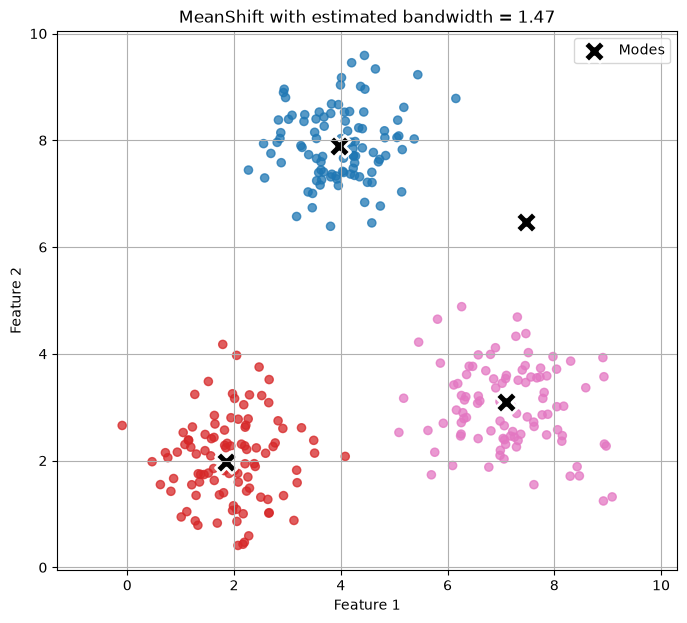

In [98]:
meanshift_demo_estimated_model = MeanShift(
    bandwidth=meanshift_demo_estimated_bw,
    bin_seeding=False
)

meanshift_demo_estimated_model.fit(meanshift_demo_X)

meanshift_demo_labels_est = meanshift_demo_estimated_model.labels_
meanshift_demo_modes_est = meanshift_demo_estimated_model.cluster_centers_

plt.figure(figsize=(8, 7))

plt.scatter(
    meanshift_demo_X[:, 0],
    meanshift_demo_X[:, 1],
    c=meanshift_demo_labels_est,
    cmap="tab10",
    s=35,
    alpha=0.75
)

plt.scatter(
    meanshift_demo_modes_est[:, 0],
    meanshift_demo_modes_est[:, 1],
    c="black",
    s=250,
    marker="X",
    edgecolors="white",
    linewidths=2,
    label="Modes"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"MeanShift with estimated bandwidth = {meanshift_demo_estimated_bw:.2f}")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


# **Part 2:** Experiment on real image data

# Phần A dùng sample pixel để thấy điểm, trajectory, mode, bandwidth.

### Mean Shift Cell 1: Import các thư viện và mô đun cần thiết
**Mục đích:** Khởi tạo môi trường tính toán số học, thao tác ma trận và vẽ đồ thị cho thuật toán Mean Shift.
**Cách hoạt động:** Nhập `numpy` để thao tác tính toán khoảng cách vector; `matplotlib` cùng đối tượng `Circle` để trực quan hóa các đường quỹ đạo dịch chuyển và vòng tròn bán kính; `MeanShift` từ thư viện `scikit-learn` để đối chiếu với thuật toán tự cài đặt.

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
from matplotlib.patches import Circle

### Mean Shift Cell 2: Đọc ảnh nguyên bản
**Mục đích:** Nạp bức ảnh đầu vào để chuẩn bị cho thực hành phân cụm.

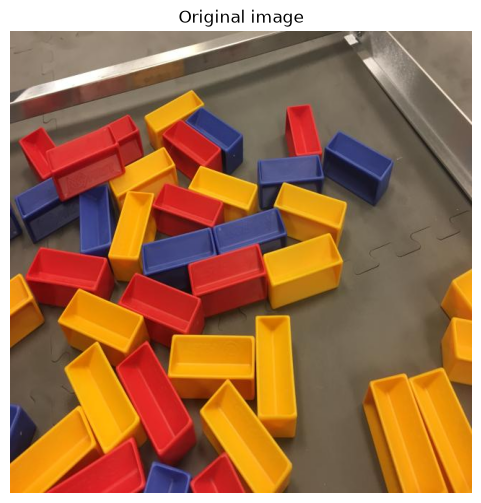

In [100]:
meanshift_image_path = "dataset/img_01.jpg"  # đổi path nếu chạy trên Colab/máy bạn

img_bgr = cv2.imread(meanshift_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()


### Mean Shift Cell 3: Chuẩn bị dữ liệu 2D (kênh L* và u*)
**Mục đích:** Lấy mẫu ngẫu nhiên 3000 điểm ảnh trong không gian L*u* để minh họa trực quan quá trình dịch chuyển cửa sổ.

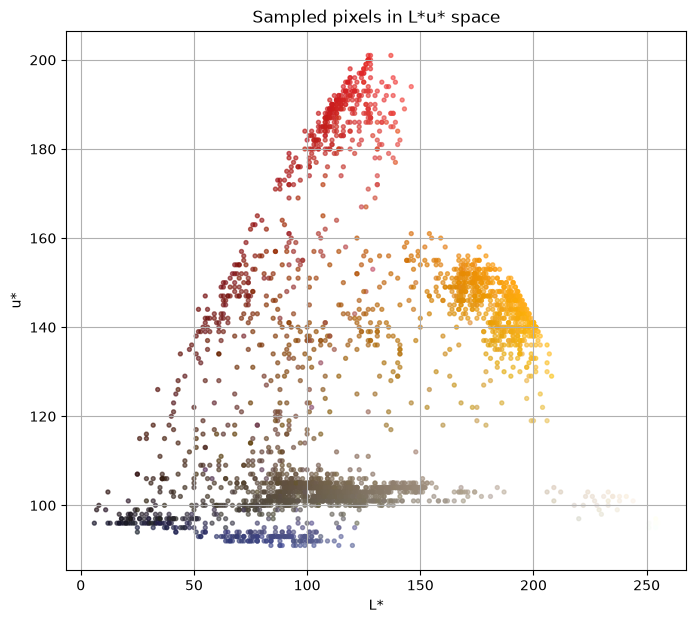

In [101]:
meanshift_img_luv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LUV)

meanshift_pixels_luv = meanshift_img_luv.reshape(-1, 3)
meanshift_pixels_rgb = img_rgb.reshape(-1, 3)

meanshift_num_samples = 3000

meanshift_sample_indices = np.random.choice(
    len(meanshift_pixels_luv),
    size=min(meanshift_num_samples, len(meanshift_pixels_luv)),
    replace=False
)

meanshift_sample_luv = meanshift_pixels_luv[meanshift_sample_indices]
meanshift_sample_rgb = meanshift_pixels_rgb[meanshift_sample_indices] / 255.0

# Chỉ lấy 2 chiều để visualize: L* và u*
meanshift_sample_lu = meanshift_sample_luv[:, [0, 1]].astype(np.float64)

plt.figure(figsize=(8, 7))
plt.scatter(
    meanshift_sample_lu[:, 0],
    meanshift_sample_lu[:, 1],
    c=meanshift_sample_rgb,
    s=8,
    alpha=0.6
)
plt.xlabel("L*")
plt.ylabel("u*")
plt.title("Sampled pixels in L*u* space")
plt.grid(True)
plt.show()


### Mean Shift Cell 4: Cài đặt thủ công thuật toán Mean Shift
**Mục đích:** Xây dựng hàm `manual_mean_shift` mô phỏng chính xác từng bước leo đồi của các cửa sổ tìm kiếm.
**Cách hoạt động:** Tại mỗi điểm xuất phát, tìm các láng giềng trong bán kính `bandwidth`, tính trung bình tọa độ (`neighbors.mean()`), dịch chuyển tâm đến đó và ghi lại quỹ đạo (`trajectory`) cho tới khi dừng.

In [102]:
def manual_mean_shift_image(sample_points, bandwidth, max_iter=30, tol=1e-2):
    meanshift_image_trajectories = []
    meanshift_image_final_points = []

    for start_point in sample_points:
        current_point = start_point.copy()
        point_trajectory = [current_point.copy()]

        for _ in range(max_iter):
            distances = np.linalg.norm(sample_points - current_point, axis=1)

            neighbors = sample_points[distances <= bandwidth]

            if len(neighbors) == 0:
                break

            new_current_point = neighbors.mean(axis=0)

            shift_distance = np.linalg.norm(new_current_point - current_point)

            point_trajectory.append(new_current_point.copy())

            current_point = new_current_point

            if shift_distance < tol:
                break

        meanshift_image_trajectories.append(np.array(point_trajectory))
        meanshift_image_final_points.append(current_point)

    return np.array(meanshift_image_final_points), meanshift_image_trajectories


### Mean Shift Cell 5: Thực thi Mean Shift thủ công
**Mục đích:** Chạy hàm dịch chuyển tâm lên 3000 điểm mẫu với bán kính `bandwidth = 30`.

In [103]:
meanshift_image_bandwidth = 30

meanshift_image_final_points, meanshift_image_trajectories = manual_mean_shift_image(
    meanshift_sample_lu,
    bandwidth=meanshift_image_bandwidth,
    max_iter=30,
    tol=1e-2
)

print("Number of sampled pixels:", len(meanshift_sample_lu))
print("Number of converged windows:", len(meanshift_image_final_points))


Number of sampled pixels: 3000
Number of converged windows: 3000


### Mean Shift Cell 6: Hàm hợp nhất các đỉnh mật độ (Merge Modes)
**Mục đích:** Gộp các cửa sổ có điểm dừng hội tụ nằm sát cạnh nhau thành một đỉnh (Mode) duy nhất.

In [104]:
def merge_mean_shift_image_modes(shifted_points, merge_distance):
    meanshift_image_modes = []
    meanshift_image_labels = np.full(len(shifted_points), fill_value=-1)

    for point_id, shifted_point in enumerate(shifted_points):
        assigned = False

        for mode_id, image_mode in enumerate(meanshift_image_modes):
            mode_distance = np.linalg.norm(shifted_point - image_mode)

            if mode_distance <= merge_distance:
                meanshift_image_labels[point_id] = mode_id
                meanshift_image_modes[mode_id] = (image_mode + shifted_point) / 2
                assigned = True
                break

        if not assigned:
            meanshift_image_modes.append(shifted_point.copy())
            meanshift_image_labels[point_id] = len(meanshift_image_modes) - 1

    return np.array(meanshift_image_modes), meanshift_image_labels


### Mean Shift Cell 7: Thực thi hợp nhất tâm cụm
**Mục đích:** Gộp tâm cụm với khoảng cách bằng nửa bandwidth, qua đó tự động phát hiện ra số lượng cụm tối ưu.

In [105]:
meanshift_image_merge_distance = meanshift_image_bandwidth / 2

meanshift_image_modes, meanshift_image_labels = merge_mean_shift_image_modes(
    meanshift_image_final_points,
    merge_distance=meanshift_image_merge_distance
)

print("Number of modes / clusters:", len(meanshift_image_modes))

for mode_id, meanshift_image_mode in enumerate(meanshift_image_modes):
    print(f"Mode {mode_id}: L*={meanshift_image_mode[0]:.2f}, u*={meanshift_image_mode[1]:.2f}")


Number of modes / clusters: 6
Mode 0: L*=104.57, u*=102.76
Mode 1: L*=182.93, u*=144.15
Mode 2: L*=234.77, u*=99.63
Mode 3: L*=80.99, u*=138.62
Mode 4: L*=116.64, u*=186.09
Mode 5: L*=125.80, u*=143.55


### Mean Shift Cell 8: Trực quan hóa Quỹ đạo leo đồi và Tâm cụm Mean Shift
**Mục đích:** Minh họa trực quan toàn bộ 'bức tranh chuyển động' bên trong thuật toán Mean Shift.
**Cách hoạt động:** 
- Vẽ đồ thị scatter hiển thị 3000 điểm mẫu tô màu theo nhãn cụm.
- Chọn ngẫu nhiên 80 đường quỹ đạo (`trajectories`) vẽ nối từ điểm xuất phát (hình tròn 'o') tới vị trí hội tụ (dấu 'x') giúp ta nhìn thấy rõ các dòng chảy dữ liệu bị hút về các đỉnh.
- Vẽ các tâm cụm Modes bằng biểu tượng chữ 'X' đen lớn kèm theo đường tròn bán kính `bandwidth` mô tả vùng ảnh hưởng vật lý.

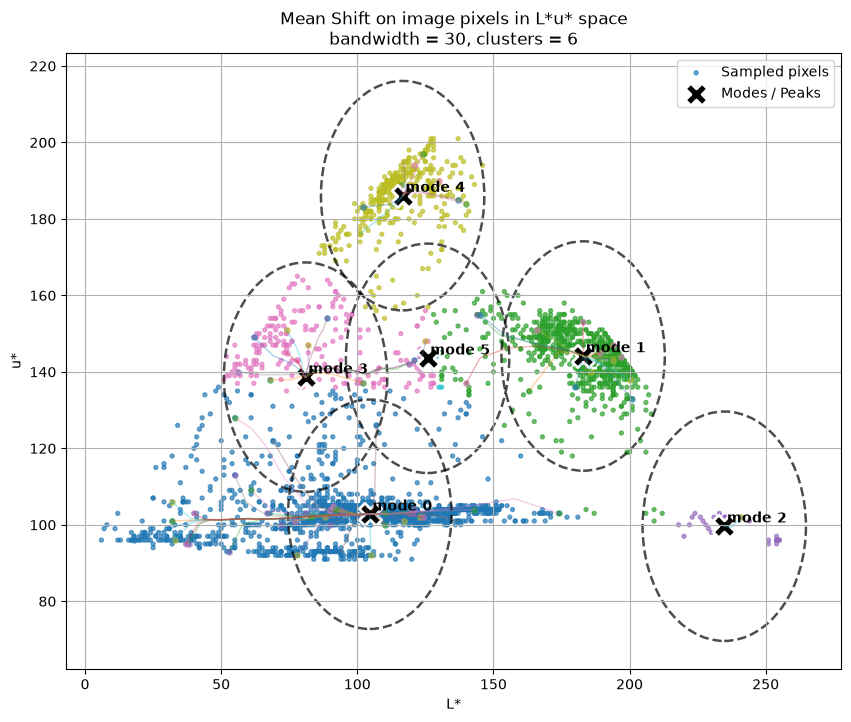

In [106]:
plt.figure(figsize=(10, 8))

# Vẽ pixel theo cluster label
plt.scatter(
    meanshift_sample_lu[:, 0],
    meanshift_sample_lu[:, 1],
    c=meanshift_image_labels,
    cmap="tab10",
    s=8,
    alpha=0.65,
    label="Sampled pixels"
)

# Chỉ vẽ một số trajectory để biểu đồ không quá rối
meanshift_num_trajectories_to_show = 80

meanshift_traj_indices = np.random.choice(
    len(meanshift_image_trajectories),
    size=min(meanshift_num_trajectories_to_show, len(meanshift_image_trajectories)),
    replace=False
)

for meanshift_traj_idx in meanshift_traj_indices:
    meanshift_traj = meanshift_image_trajectories[meanshift_traj_idx]

    plt.plot(
        meanshift_traj[:, 0],
        meanshift_traj[:, 1],
        linewidth=1,
        alpha=0.35
    )

    # điểm bắt đầu
    plt.scatter(
        meanshift_traj[0, 0],
        meanshift_traj[0, 1],
        s=15,
        marker="o",
        alpha=0.5
    )

    # điểm hội tụ
    plt.scatter(
        meanshift_traj[-1, 0],
        meanshift_traj[-1, 1],
        s=25,
        marker="x",
        alpha=0.8
    )

# Vẽ mode / peak
plt.scatter(
    meanshift_image_modes[:, 0],
    meanshift_image_modes[:, 1],
    c="black",
    s=260,
    marker="X",
    edgecolors="white",
    linewidths=2,
    label="Modes / Peaks"
)

# Vẽ bandwidth quanh mode
for mode_id, meanshift_image_mode in enumerate(meanshift_image_modes):
    meanshift_circle = Circle(
        (meanshift_image_mode[0], meanshift_image_mode[1]),
        radius=meanshift_image_bandwidth,
        fill=False,
        linestyle="--",
        linewidth=1.8,
        alpha=0.7
    )

    plt.gca().add_patch(meanshift_circle)

    plt.text(
        meanshift_image_mode[0] + 1,
        meanshift_image_mode[1] + 1,
        f"mode {mode_id}",
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel("L*")
plt.ylabel("u*")
plt.title(f"Mean Shift on image pixels in L*u* space\nbandwidth = {meanshift_image_bandwidth}, clusters = {len(meanshift_image_modes)}")
plt.grid(True)
plt.legend()
plt.show()


# Phần B: Áp dụng Mean Shift lên ảnh màu thật

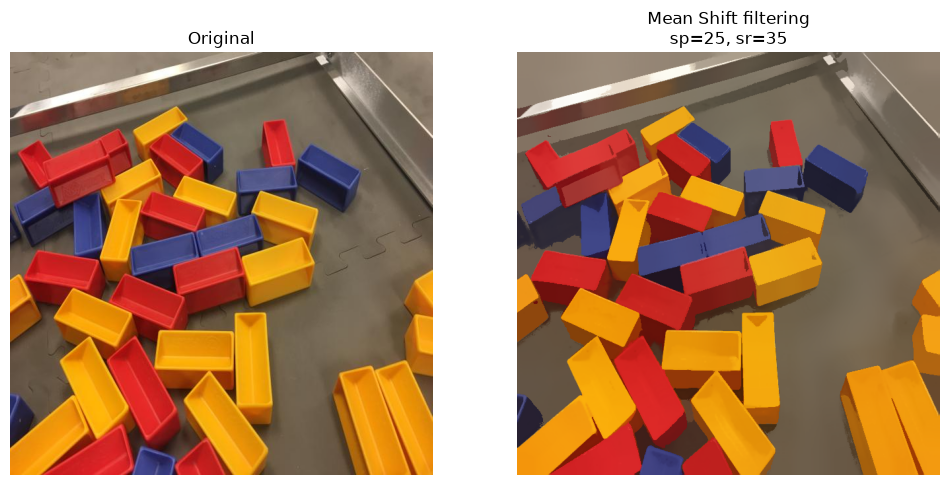

In [107]:
# sp: spatial window radius
# sr: color window radius

import cv2

meanshift_sp = 25
meanshift_sr = 35

meanshift_filtered_bgr = cv2.pyrMeanShiftFiltering(
    img_bgr,
    sp=meanshift_sp,
    sr=meanshift_sr
)

meanshift_filtered_rgb = cv2.cvtColor(meanshift_filtered_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(meanshift_filtered_rgb)
plt.axis("off")
plt.title(f"Mean Shift filtering\nsp={meanshift_sp}, sr={meanshift_sr}")

plt.show()


### Mean Shift Cell 10: Khảo sát ảnh hưởng của cặp tham số (sp, sr)
**Mục đích:** So sánh các mức độ bệt màu (posterization) khác nhau khi tăng dần bán kính cửa sổ.

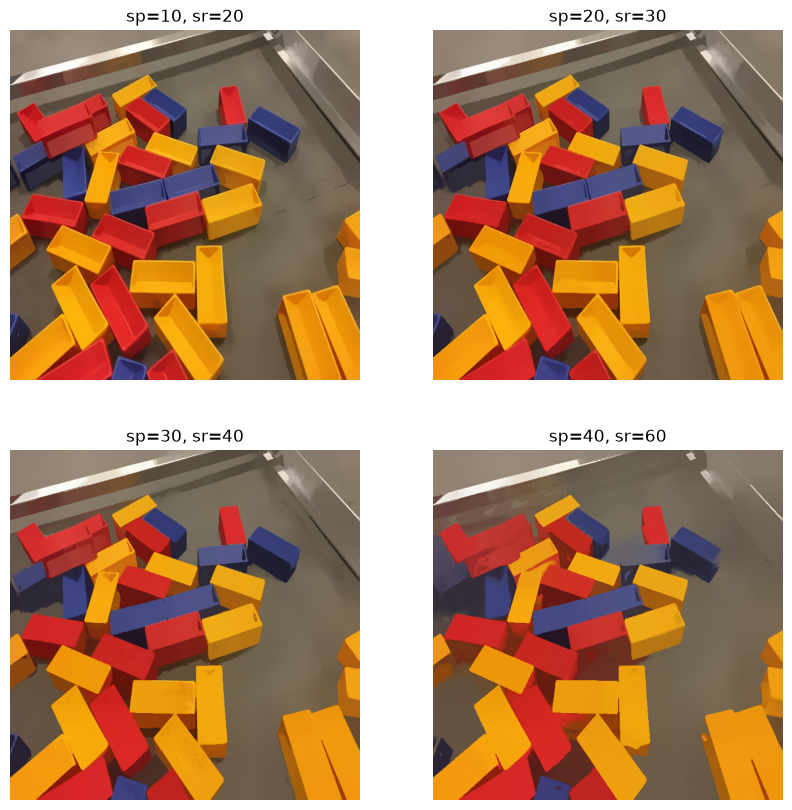

In [108]:
meanshift_param_grid = [
    (10, 20),
    (20, 30),
    (30, 40),
    (40, 60)
]

plt.figure(figsize=(10, 10))

for grid_id, (grid_sp, grid_sr) in enumerate(meanshift_param_grid):
    meanshift_grid_filtered_bgr = cv2.pyrMeanShiftFiltering(
        img_bgr,
        sp=grid_sp,
        sr=grid_sr
    )

    meanshift_grid_filtered_rgb = cv2.cvtColor(meanshift_grid_filtered_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, grid_id + 1)
    plt.imshow(meanshift_grid_filtered_rgb)
    plt.axis("off")
    plt.title(f"sp={grid_sp}, sr={grid_sr}")

plt.show()


### Mean Shift Cell 11: Phân vùng màu duy nhất (Unique Color Regions)
**Mục đích:** Tìm các màu độc lập sau khi lọc và tạo bản đồ nhãn phân vùng.

Number of unique color regions: 17370


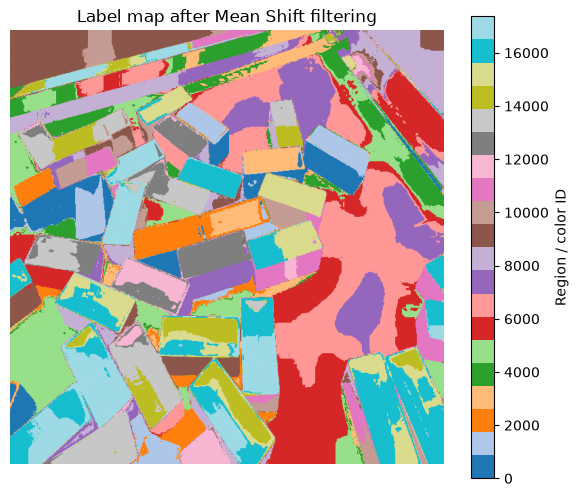

In [109]:
meanshift_region_sp = 25
meanshift_region_sr = 35

meanshift_region_bgr = cv2.pyrMeanShiftFiltering(
    img_bgr,
    sp=meanshift_region_sp,
    sr=meanshift_region_sr
)

meanshift_region_rgb = cv2.cvtColor(meanshift_region_bgr, cv2.COLOR_BGR2RGB)

meanshift_region_pixels_rgb = meanshift_region_rgb.reshape(-1, 3)

# Tìm các màu unique sau filtering
meanshift_unique_colors, meanshift_inverse_region_labels = np.unique(
    meanshift_region_pixels_rgb,
    axis=0,
    return_inverse=True
)

meanshift_region_label_img = meanshift_inverse_region_labels.reshape(img_rgb.shape[:2])

print("Number of unique color regions:", len(meanshift_unique_colors))

plt.figure(figsize=(7, 6))
plt.imshow(meanshift_region_label_img, cmap="tab20")
plt.axis("off")
plt.title("Label map after Mean Shift filtering")
plt.colorbar(label="Region / color ID")
plt.show()


### Mean Shift Cell 12: Kết hợp Mean Shift + K-Means
**Mục đích:** Gom cụm tiếp hàng trăm vùng màu sau filtering xuống đúng $K=6$ cụm màu chủ đạo bằng K-Means.

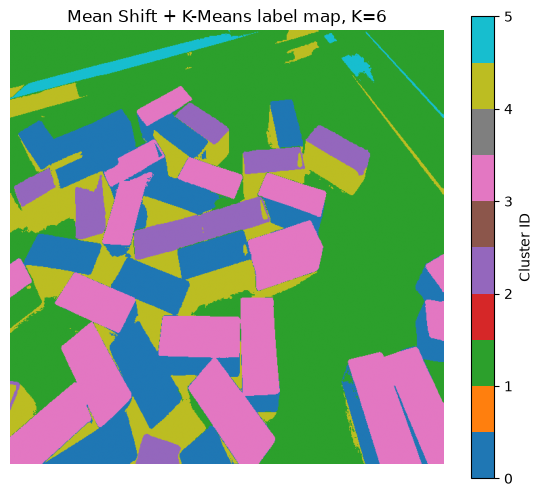

In [110]:
from sklearn.cluster import KMeans

meanshift_kmeans_k = 6

meanshift_kmeans_pixels_luv = cv2.cvtColor(
    meanshift_region_rgb,
    cv2.COLOR_RGB2LUV
).reshape(-1, 3)

meanshift_kmeans_model = KMeans(
    n_clusters=meanshift_kmeans_k,
    random_state=42,
    n_init=10
)

meanshift_kmeans_labels = meanshift_kmeans_model.fit_predict(meanshift_kmeans_pixels_luv)

meanshift_kmeans_label_img = meanshift_kmeans_labels.reshape(img_rgb.shape[:2])

plt.figure(figsize=(7, 6))
plt.imshow(meanshift_kmeans_label_img, cmap="tab10")
plt.axis("off")
plt.title(f"Mean Shift + K-Means label map, K={meanshift_kmeans_k}")
plt.colorbar(label="Cluster ID")
plt.show()


### Mean Shift Cell 13: Tái tạo ảnh Phân đoạn Mean Shift
**Mục đích:** Hiển thị kết quả phân đoạn ảnh hoàn chỉnh của phương pháp Mean Shift.

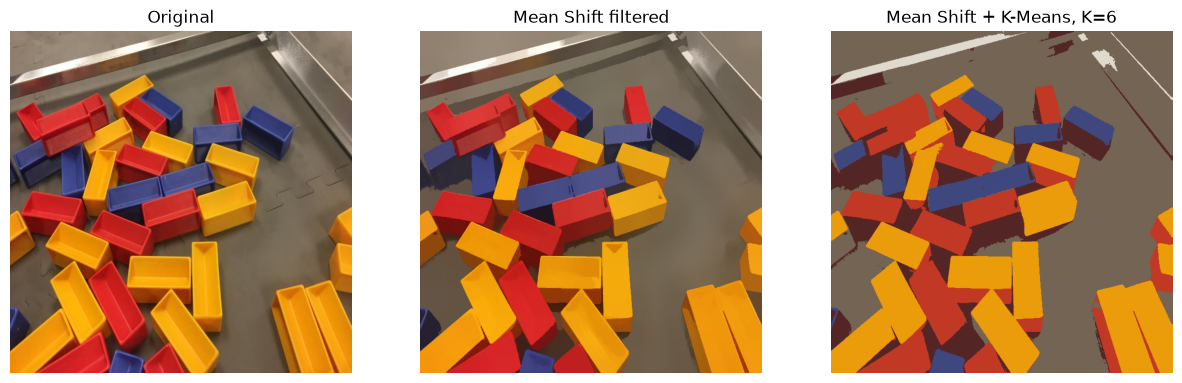

In [111]:
meanshift_kmeans_centers_luv = meanshift_kmeans_model.cluster_centers_

meanshift_kmeans_segmented_luv = meanshift_kmeans_centers_luv[meanshift_kmeans_labels]
meanshift_kmeans_segmented_luv = meanshift_kmeans_segmented_luv.reshape(img_rgb.shape).astype(np.uint8)

meanshift_kmeans_segmented_rgb = cv2.cvtColor(meanshift_kmeans_segmented_luv, cv2.COLOR_LUV2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(meanshift_region_rgb)
plt.axis("off")
plt.title("Mean Shift filtered")

plt.subplot(1, 3, 3)
plt.imshow(meanshift_kmeans_segmented_rgb)
plt.axis("off")
plt.title(f"Mean Shift + K-Means, K={meanshift_kmeans_k}")

plt.show()


# Tổng kết: So sánh Phân đoạn ảnh (Image Segmentation) giữa 3 phương pháp
**Mục đích:** Đặt cạnh nhau kết quả phân đoạn ảnh của cả 3 phương pháp đã thực hành trong bài (**K-Means**, **Gaussian Mixture Model**, và **Mean Shift**) để đánh giá trực quan ưu nhược điểm thực tế trên cùng một bức ảnh.


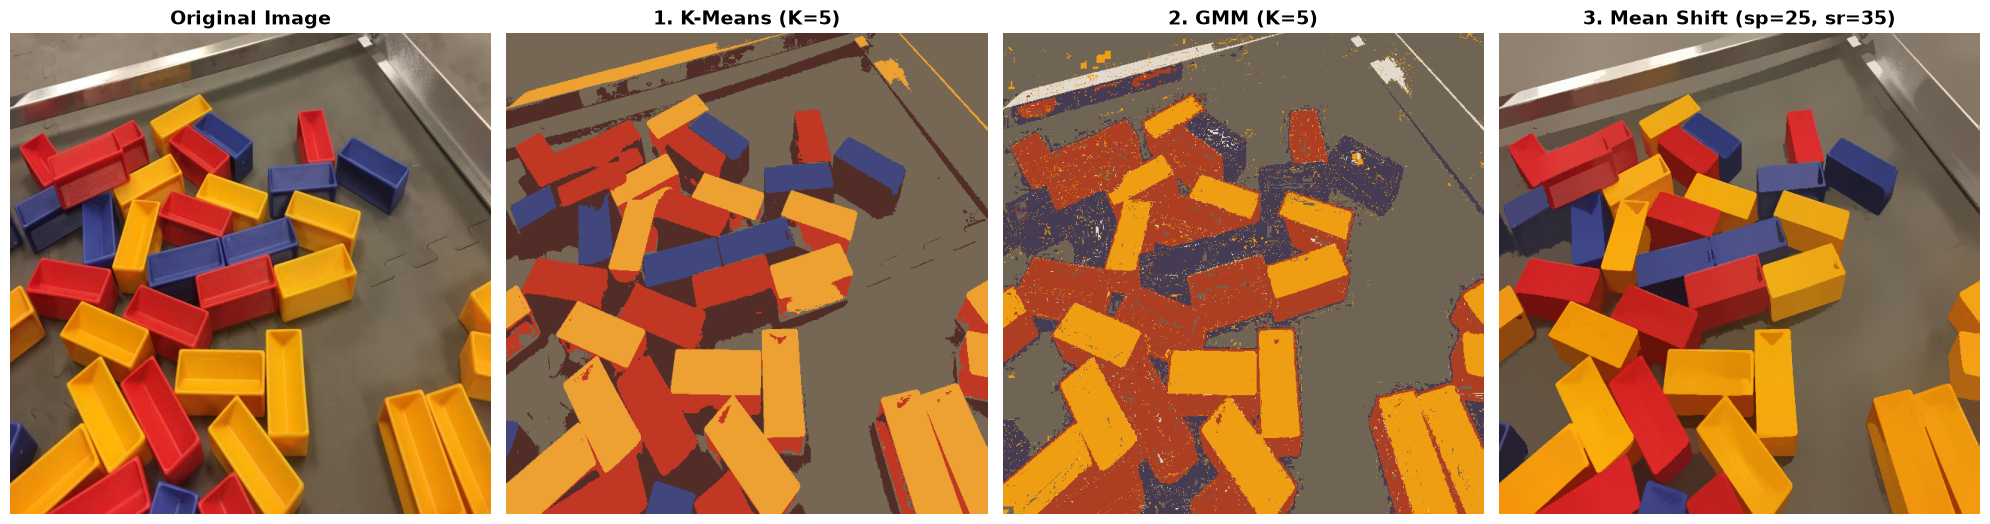

In [112]:
# Task cuối cùng: So sánh 3 phương pháp segmentation

comparison_images = [
    ("Original Image", img_rgb),
    (f"1. K-Means (K={kmeans_k})", kmeans_segmented_rgb),
    (f"2. GMM (K={gmm_k})", gmm_segmented_rgb),
    (f"3. Mean Shift (sp={meanshift_sp}, sr={meanshift_sr})", meanshift_filtered_rgb),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, (title, image) in zip(axes, comparison_images):
    ax.imshow(image)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()


### Chú thích thực thi Code
**Mục đích:** Thực thi khối lệnh tính toán và xử lý dữ liệu cho bài toán.